# Customer Churn Prediction using Machine Learning

## Project Overview

This project predicts customer churn using machine learning techniques. It also demonstrates customer segmentation using K-Means clustering and Customer Lifetime Value (CLTV) prediction using Linear Regression. The project covers the complete Scikit-learn workflow including preprocessing, feature engineering, model evaluation, hyperparameter tuning, PCA, pipelines, and model persistence.

# Import Libraries

Import the libraries required for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

Load the customer churn dataset into a Pandas DataFrame for analysis.

In [2]:
# Load dataset
df = pd.read_excel("data/Telco_customer_churn.xlsx")

# Data Understanding

Explore the dataset structure, data types, summary statistics, and missing values.

In [3]:
# Dataset information
df.info()

# Statistical summary
print(df.describe(include="all"))

# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

# Data Cleaning

Prepare the dataset by handling missing values, fixing data types, and removing unnecessary features.

In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Churn Reason    5174
dtype: int64


In [5]:
print(df["Churn Label"].value_counts())

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


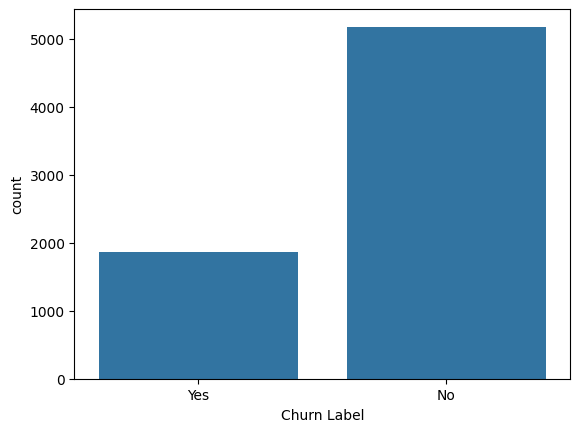

In [6]:
sns.countplot(x="Churn Label", data=df)
plt.show()

In [7]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "Lat Long",
    "Churn Reason"
]

df = df.drop(columns=drop_cols)

df.head()

,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


In [8]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [9]:
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

In [10]:
df.isnull().sum()

State                0
City                 0
Zip Code             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
dtype: int64

# Exploratory Data Analysis (EDA)

Analyze the dataset using visualizations to identify important patterns and relationships.

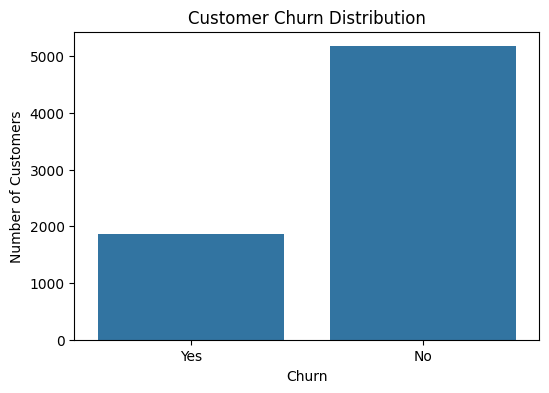

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Churn Label", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("images/Churn Distribution.png")
plt.show()

In [12]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

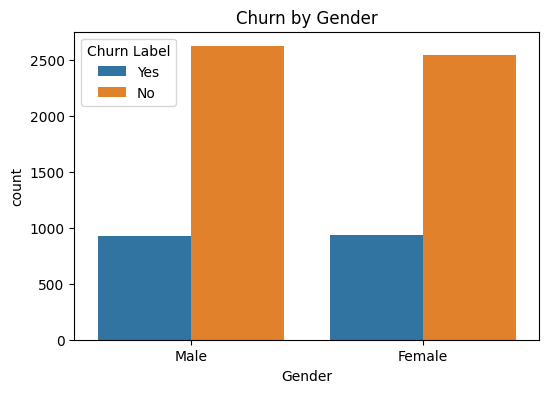

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Churn Label", data=df)

plt.title("Churn by Gender")
plt.savefig("images/GenderVsChurn.png")
plt.show()

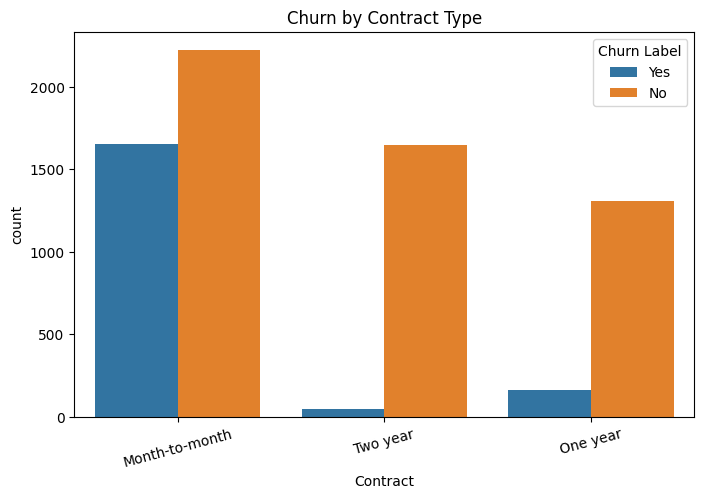

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn Label", data=df)

plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.savefig("images/ContractVsChurn.png")

plt.show()

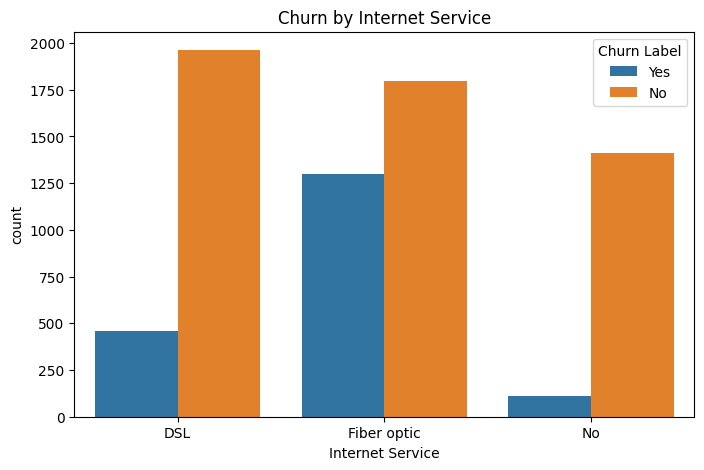

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x="Internet Service", hue="Churn Label", data=df)

plt.title("Churn by Internet Service")
plt.savefig("images/InternetServiceVsChurn.png")

plt.show()

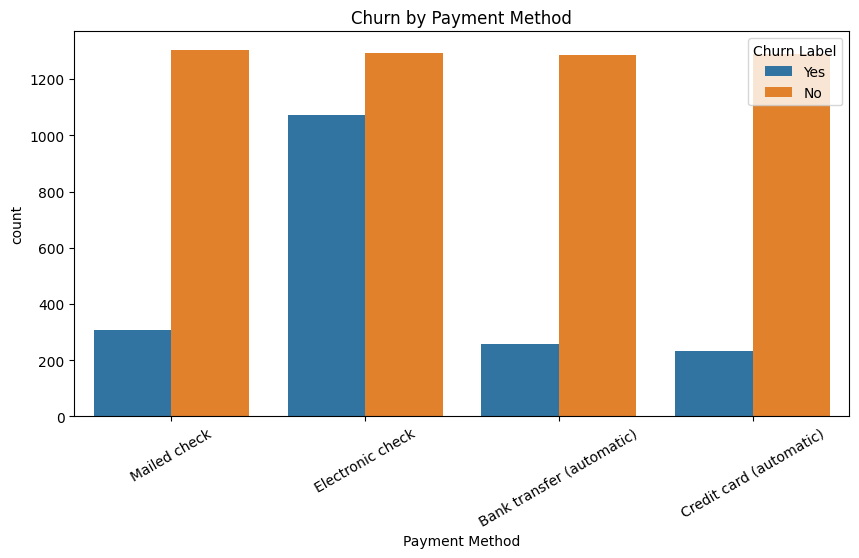

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(x="Payment Method", hue="Churn Label", data=df)

plt.xticks(rotation=30)

plt.title("Churn by Payment Method")
plt.savefig("images/PaymentMethodVsChurn.png")

plt.show()

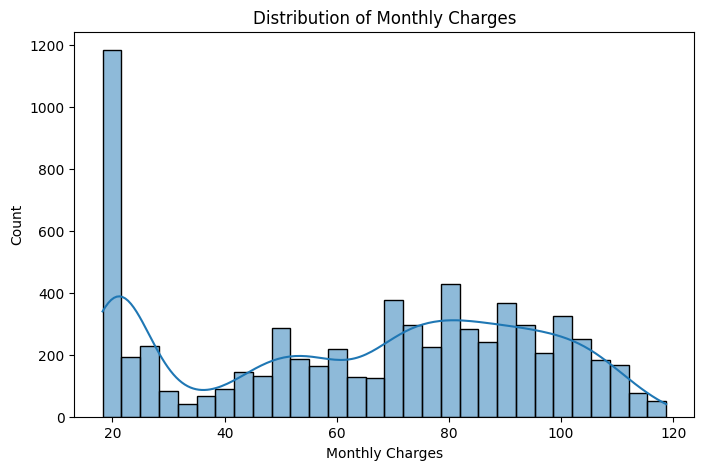

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Monthly Charges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.savefig("images/MonthlyCharges.png")

plt.show()

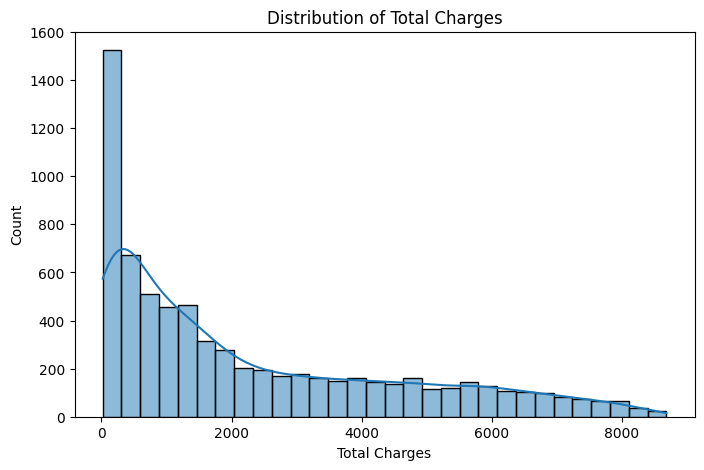

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total Charges"], bins=30, kde=True)

plt.title("Distribution of Total Charges")

plt.savefig("images/TotalChanges.png")
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=["number"])

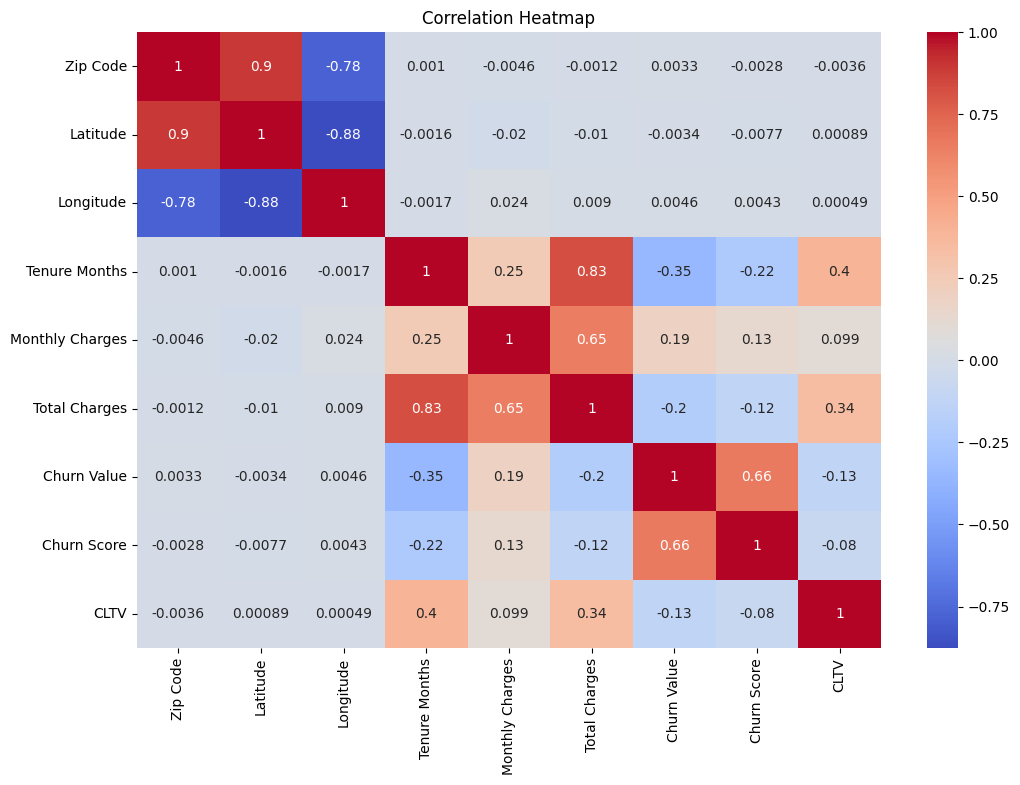

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("images/Heatmap.png")

plt.show()

# Feature Engineering

Prepare the feature set and target variable for machine learning.

In [21]:
X = df.drop(columns=["Churn Label", "CLTV"])
y = df["Churn Label"]

print(X.shape)
print(y.shape)

(7043, 26)
(7043,)


In [22]:
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['State', 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical Columns:
['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score']


# Feature Encoding

Convert categorical variables into numerical values suitable for machine learning algorithms.

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [24]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)
X.head()

(7043, 1163)


,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,City_Acton,City_Adelanto,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,90003,33.964131,-118.272783,2,53.85,108.15,1,86,False,False,...,False,False,False,False,False,False,True,False,False,True
1,90005,34.059281,-118.307420,2,70.70,151.65,1,67,False,False,...,False,False,False,False,False,False,True,False,True,False
2,90006,34.048013,-118.293953,8,99.65,820.50,1,86,False,False,...,False,True,False,True,False,False,True,False,True,False
3,90010,34.062125,-118.315709,28,104.80,3046.05,1,84,False,False,...,False,True,False,True,False,False,True,False,True,False
4,90015,34.039224,-118.266293,49,103.70,5036.30,1,89,False,False,...,False,True,False,True,False,False,True,False,False,False


# Train-Test Split

Split the dataset into training and testing sets for model development and evaluation.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# stratify - y keeps the same percentage of churned and non-churned customers in both training and testing sets.

Training Shape : (5634, 1163)
Testing Shape  : (1409, 1163)


# Feature Scaling

Standardize numerical features to improve model performance.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# KNN Classification Model

Train a K-Nearest Neighbors classifier to predict customer churn.

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Model Evaluation

Evaluate the classification model using multiple performance metrics.

In [28]:
y_pred = knn.predict(X_test_scaled)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0]


In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7806955287437899


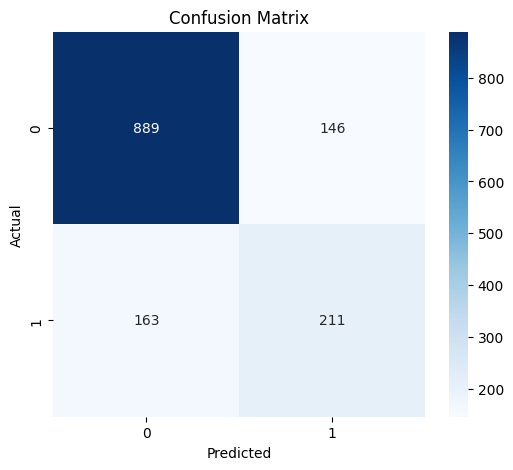

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.59      0.56      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [32]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

Precision : 0.5910364145658263
Recall    : 0.5641711229946524
F1 Score  : 0.5772913816689467


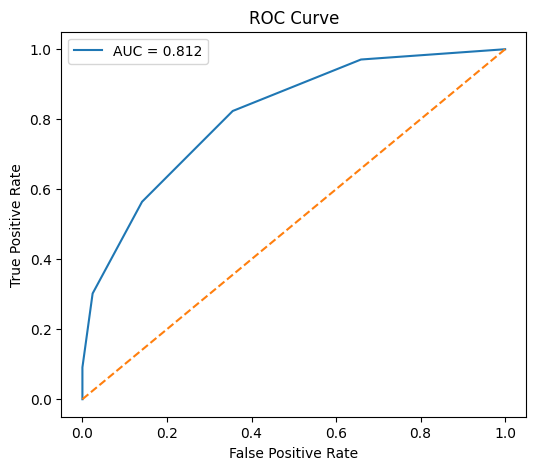

In [33]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_prob = knn.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.savefig("images/ROC_Curve.png")

plt.legend()

plt.show()

In [34]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score :", auc)

ROC-AUC Score : 0.8124105505179674


# Cross Validation

Assess the model's performance and stability using cross-validation.

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    KNeighborsClassifier(),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)

[0.76579134 0.78140525 0.77430802 0.77556818 0.77911932]


In [36]:
print(f"Average Cross Validation Accuracy: {scores.mean():.4f}")

Average Cross Validation Accuracy: 0.7752


In [37]:
train_scores = []
test_scores = []

neighbors = range(1,21)

for k in neighbors:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    train_scores.append(model.score(X_train_scaled, y_train))

    test_scores.append(model.score(X_test_scaled, y_test))

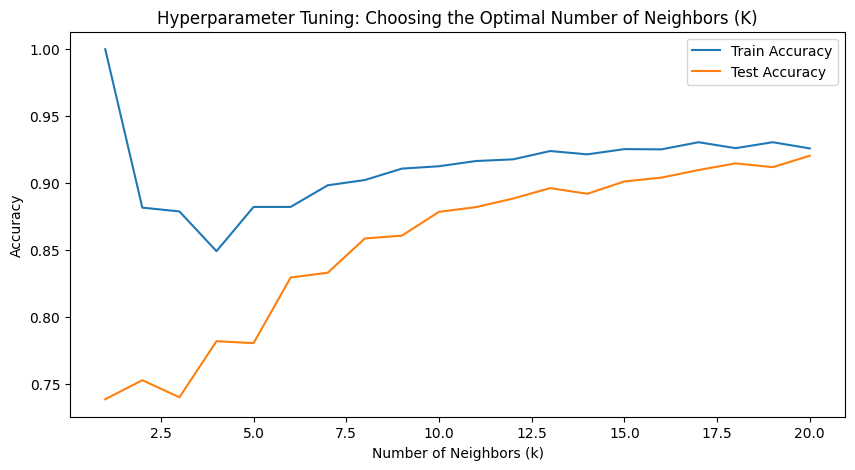

In [38]:
plt.figure(figsize=(10,5))

plt.plot(neighbors, train_scores, label="Train Accuracy")

plt.plot(neighbors, test_scores, label="Test Accuracy")

plt.xlabel("Number of Neighbors (k)")

plt.ylabel("Accuracy")

plt.title("Hyperparameter Tuning: Choosing the Optimal Number of Neighbors (K)")
plt.savefig("images/Best_K.png")

plt.legend()

plt.show()

In [39]:
best_k = neighbors[test_scores.index(max(test_scores))]

print("Best K:", best_k)

print("Best Accuracy:", max(test_scores))

Best K: 20
Best Accuracy: 0.9205110007097232


# Hyperparameter Tuning

Optimize the KNN model by finding the best hyperparameter values.

In [40]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

In [41]:
grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [42]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}


In [43]:
print("Best Cross Validation Score:")
print(grid.best_score_)

Best Cross Validation Score:
0.9373425731401527


In [44]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9325762952448545


# Principal Component Analysis (PCA)

Reduce the dimensionality of the dataset while preserving most of the information.

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [46]:
print("Original Features :", X_train.shape[1])
print(f"Features Before PCA : {X_train.shape[1]}")
print(f"Features After PCA  : {pca.n_components_}")
print(f"Variance Preserved  : {pca.explained_variance_ratio_.sum():.4f}")

Original Features : 1163
Features Before PCA : 1163
Features After PCA  : 1079
Variance Preserved  : 0.9500


In [47]:
print("Total Variance Preserved:",
      pca.explained_variance_ratio_.sum())

Total Variance Preserved: 0.9500169344225908


In [48]:
knn_pca = KNeighborsClassifier(
    metric="manhattan",
    n_neighbors=19,
    weights="uniform"
)

knn_pca.fit(X_train_pca, y_train)

y_pred_pca = knn_pca.predict(X_test_pca)

In [49]:
from sklearn.metrics import accuracy_score

print("Accuracy after PCA:",
      accuracy_score(y_test, y_pred_pca))

Accuracy after PCA: 0.8715400993612491


# Machine Learning Pipeline

Build an automated pipeline to streamline preprocessing and model training.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [51]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1163,)","['Zip Code','Latitude','Longitude',..., 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check','Payment Method_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1163
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [52]:
y_pred_pipe = pipe.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

print("Pipeline Accuracy:",
      accuracy_score(y_test, y_pred_pipe))

Pipeline Accuracy: 0.7806955287437899


In [54]:
params = {
    "knn__n_neighbors": range(1,21),
    "knn__weights": ["uniform","distance"],
    "knn__metric": ["euclidean","manhattan","minkowski"]
}

In [55]:
grid_pipe = GridSearchCV(
    pipe,
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_pipe.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan', ...], 'knn__n_neighbors': range(1, 21), 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

In [56]:
print(grid_pipe.best_params_)
print(grid_pipe.best_score_)

{'knn__metric': 'manhattan', 'knn__n_neighbors': 20, 'knn__weights': 'uniform'}
0.9368109742931848


In [57]:
best_pipe = grid_pipe.best_estimator_

y_pred = best_pipe.predict(X_test)

print("Pipeline Accuracy:",
      accuracy_score(y_test, y_pred))

Pipeline Accuracy: 0.9318665720369056


In [58]:
X_cluster = df.drop(columns=[
    "Churn Label",
    "City",
    "State",
    "Zip Code",
    "Latitude",
    "Longitude"
])

In [59]:
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)

X_cluster_pca = pca.fit_transform(X_cluster_scaled)

# Customer Segmentation (K-Means)

Group customers into meaningful segments using K-Means clustering.

In [62]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X_cluster_pca)

df["Cluster"] = clusters

In [63]:
print(df["Cluster"].value_counts())

Cluster
2    3154
1    2363
0    1526
Name: count, dtype: int64


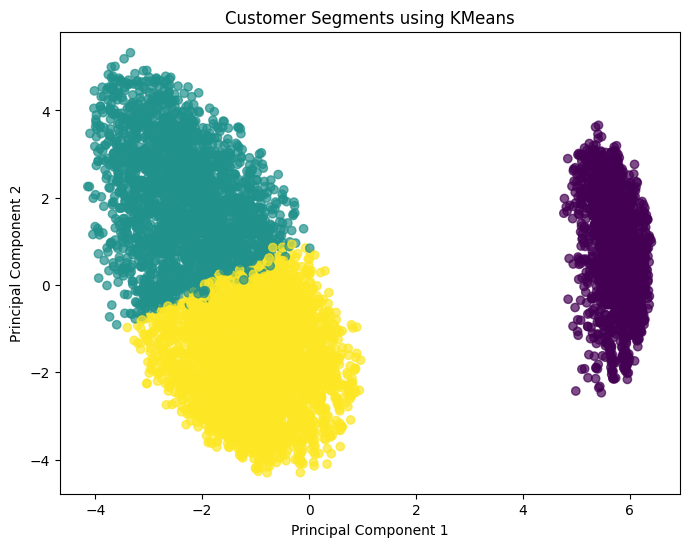

In [64]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(X_cluster_pca)

plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using KMeans")

plt.show()

In [65]:
df.groupby("Cluster").mean(numeric_only=True)

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Cluster,,,,,,,,,
0,93560.701180,36.388908,-119.932553,30.547182,21.079194,668.099443,0.074050,52.743119,4374.382045
1,93507.014388,36.240546,-119.765832,55.505713,88.006602,4907.771054,0.104528,53.245028,4918.764283
2,93514.423589,36.262318,-119.758965,15.921053,68.481341,1095.421108,0.478440,65.667724,4024.393152


# Customer Lifetime Value Prediction (Regression)

Predict the Customer Lifetime Value (CLTV) using a Linear Regression model.

In [66]:
X_reg = df.drop(columns=["CLTV", "Churn Label", "Cluster"])

y_reg = df["CLTV"]

In [67]:
X_reg = pd.get_dummies(
    X_reg,
    drop_first=True
)

In [68]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)

X_test_reg_scaled = scaler.transform(X_test_reg)

In [70]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1163,)","[ 6155.95,-1600.93, 451.04,..., 15.5 , 15.01, -28.34]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4406
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1163
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1155
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1163,)","[240.45,154.23,144.57,..., 0. , 0. , 0. ]"


In [71]:
y_pred = lr.predict(X_test_reg_scaled)

In [72]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE :", mean_absolute_error(y_test_reg, y_pred))
print("MSE :", mean_squared_error(y_test_reg, y_pred))
print("RMSE :", mean_squared_error(y_test_reg, y_pred) ** 0.5)
print("R2 :", r2_score(y_test_reg, y_pred))

MAE : 1243.8015148786044
MSE : 2565643.0192763214
RMSE : 1601.7624728018575
R2 : -0.8886457603734144


# Model Persistence

Save and reload the trained machine learning model using Joblib.

In [73]:
import joblib

joblib.dump(best_pipe, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [74]:
loaded_model = joblib.load("customer_churn_model.pkl")

In [75]:
print("Columns used for prediction:")
print(X_test.columns)

Columns used for prediction:
Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'Churn Score', 'City_Acton',
       'City_Adelanto',
       ...
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='str', length=1163)


In [76]:
print("Does X_test contain CLTV?")
print("CLTV" in X_test.columns)

Does X_test contain CLTV?
False


In [77]:
loaded_predictions = loaded_model.predict(X_test)

print(loaded_predictions[:10])

[0 0 0 0 0 0 0 0 0 1]


In [78]:
from sklearn.metrics import accuracy_score

print("Loaded Model Accuracy:",
      accuracy_score(y_test, loaded_predictions))

Loaded Model Accuracy: 0.9318665720369056


# Predicting a New Customer

Use the trained model to predict the churn status of a new customer.

In [79]:
new_customer = X_test.iloc[[0]]

prediction = loaded_model.predict(new_customer)

probability = loaded_model.predict_proba(new_customer)

print("Prediction :", prediction)
print("Probability :", probability)

Prediction : [0]
Probability : [[1. 0.]]


In [80]:
if prediction[0] == 1:
    print("Prediction : Churn")
else:
    print("Prediction : No Churn")

Prediction : No Churn


# Business Insights
The following insights were obtained from the analysis and machine learning models.

Customers with month-to-month contracts are more likely to churn.
Customers with higher monthly charges tend to have higher churn rates.
Hyperparameter tuning significantly improved model performance.
PCA reduced dimensionality but slightly decreased classification accuracy.
The KNN model achieved approximately 93% accuracy after tuning.
K-Means clustering successfully segmented customers into three meaningful groups, enabling personalized marketing, improved customer retention, and better business decision-making.

# Conclusion
This project demonstrated a complete end-to-end machine learning workflow using Scikit-learn. The dataset was cleaned, explored, and preprocessed before building predictive models. K-Nearest Neighbors achieved the best classification performance after hyperparameter tuning. PCA, pipelines, clustering, and regression were also implemented to demonstrate different machine learning techniques. The trained model was saved using Joblib for future use.

#### The trained model achieved approximately 93% classification accuracy after hyperparameter tuning, demonstrating the effectiveness of the complete Scikit-learn workflow.